In [1]:
from google.colab import files
uploaded = files.upload()

Saving Dataset exploration (1).zip to Dataset exploration (1).zip


In [3]:
import pandas as pd
import zipfile
import os

# Unzip the uploaded file first
with zipfile.ZipFile('Dataset exploration (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Correcting the path to one of the available CSV files
csv_file_path = 'Dataset exploration/day.csv'

# Check if the file exists at the assumed path
if not os.path.exists(csv_file_path):
    # If not, try to list the contents of the extracted directory to find the correct path
    print(f"File not found at {csv_file_path}. Listing contents of 'Dataset exploration' folder:")
    for root, dirs, files in os.walk('Dataset exploration'):
        for name in files:
            print(os.path.join(root, name))
    # If the file exists but has a different name or path, adjust csv_file_path accordingly

df = pd.read_csv(csv_file_path, encoding='unicode_escape')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display first 5 rows
df.head()

# Basic info
df.info()

# Shape of dataset
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


(731, 16)

In [5]:
# Check for null values in each column
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
# Display data type info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
# Display data type info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [8]:
#clean column names
df.columns=df.columns.str.strip()

In [9]:
# Convert 'dteday' column to datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Convert these numerical categorical columns to category type
cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

for col in cat_cols:
    df[col] = df[col].astype('category')

# Verify changes
df.dtypes

,0
instant,int64
dteday,datetime64[ns]
season,category
yr,category
mnth,category
holiday,category
weekday,category
workingday,category
weathersit,category
temp,float64


In [10]:
# Numeric columns → mean
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns → mode
cat_cols = df.select_dtypes(include=['category', 'object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [11]:
import numpy as np

# Select only numeric columns for outlier removal
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter values within bounds
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df.reset_index(drop=True, inplace=True)

In [12]:
cols_to_drop = ['instant', 'casual', 'registered']

df.drop(columns=cols_to_drop, inplace=True)

In [13]:
# Save cleaned dataset to CSV
df.to_csv('cleaned_bike_data.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


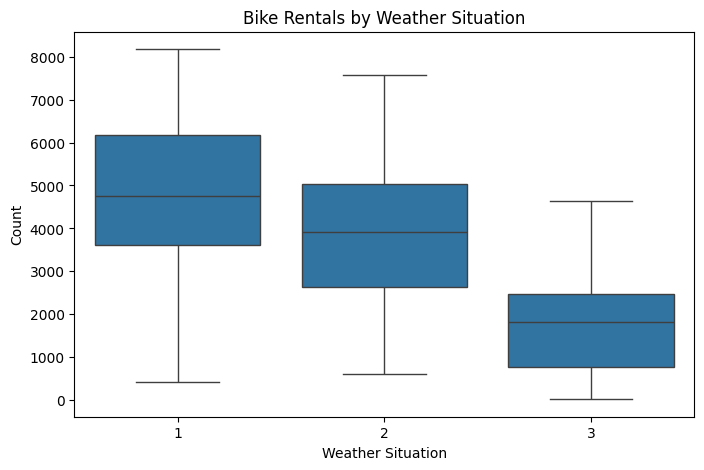

In [14]:
#weather vs bike

plt.figure(figsize=(8,5))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title("Bike Rentals by Weather Situation")
plt.xlabel("Weather Situation")
plt.ylabel("Count")
plt.show()

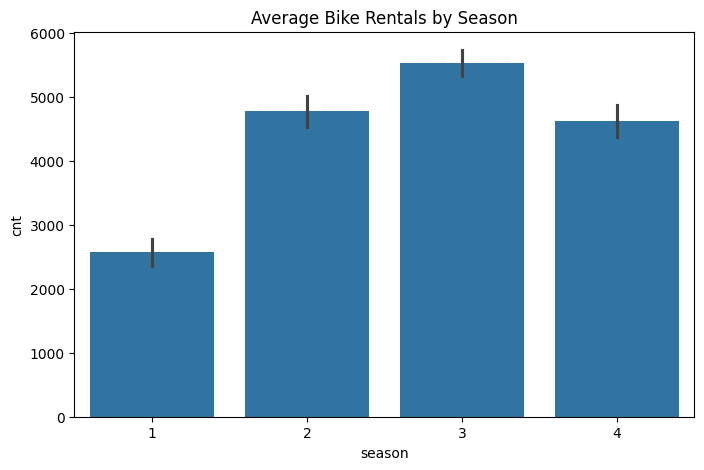

In [15]:
#rentals per season

plt.figure(figsize=(8,5))
sns.barplot(x='season', y='cnt', data=df, estimator='mean')
plt.title("Average Bike Rentals by Season")
plt.show()

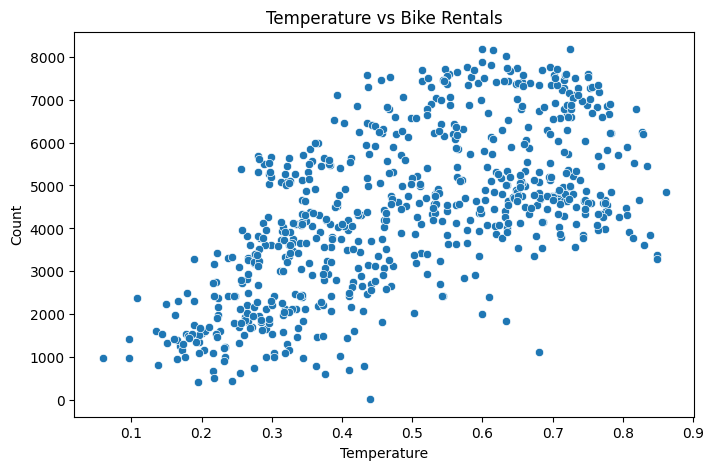

In [16]:
#temperature vs count

plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temperature vs Bike Rentals")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.show()


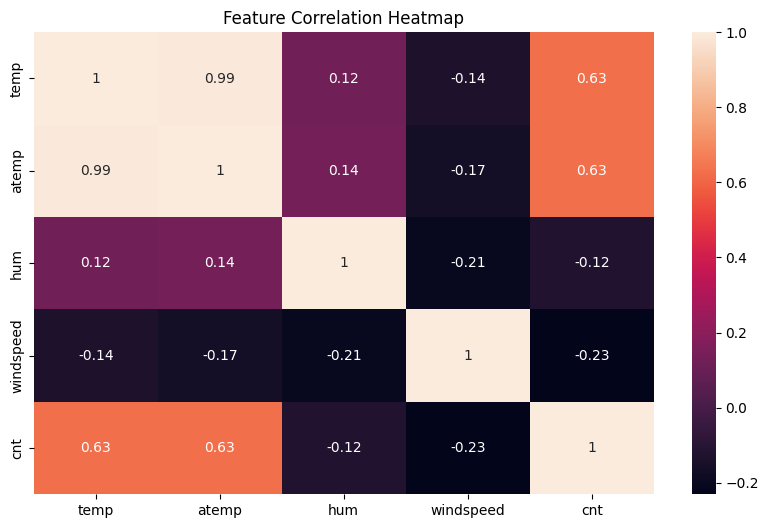

In [17]:
#correlation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

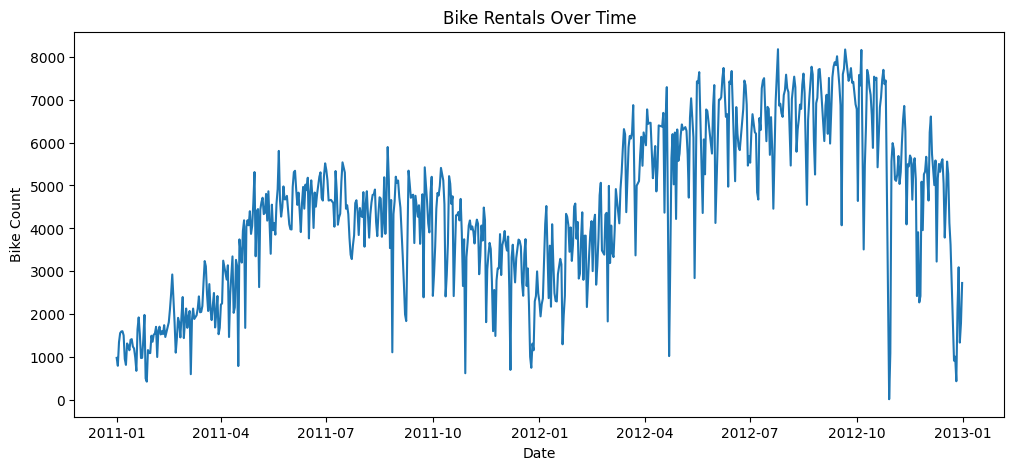

In [18]:
#rentals treand over time

plt.figure(figsize=(12,5))
plt.plot(df['dteday'], df['cnt'])
plt.title("Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Bike Count")
plt.show()

/tmp/ipython-input-3211467463.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_data = df.groupby('mnth')['cnt'].mean()


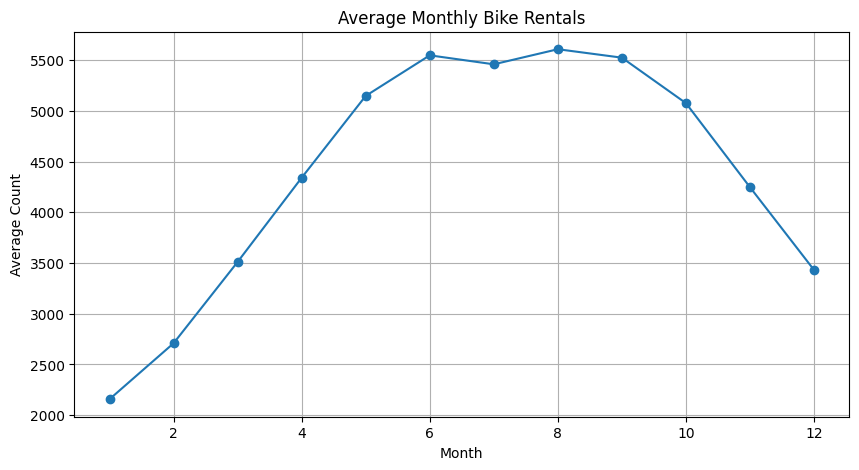

In [19]:
#monthly rental patterns

# Group by month and get average rental count
monthly_data = df.groupby('mnth')['cnt'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_data, marker='o')
plt.title("Average Monthly Bike Rentals")
plt.xlabel("Month")
plt.ylabel("Average Count")
plt.grid(True)
plt.show()

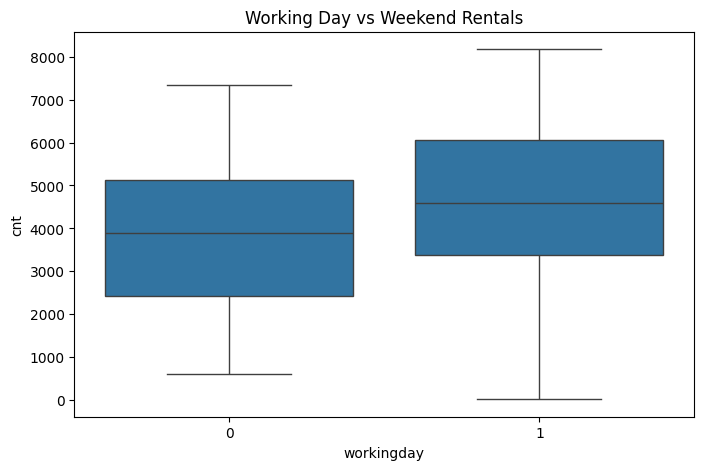

In [20]:
#working day vs weekend compariosn

plt.figure(figsize=(8,5))
sns.boxplot(x='workingday', y='cnt', data=df)
plt.title("Working Day vs Weekend Rentals")
plt.show()

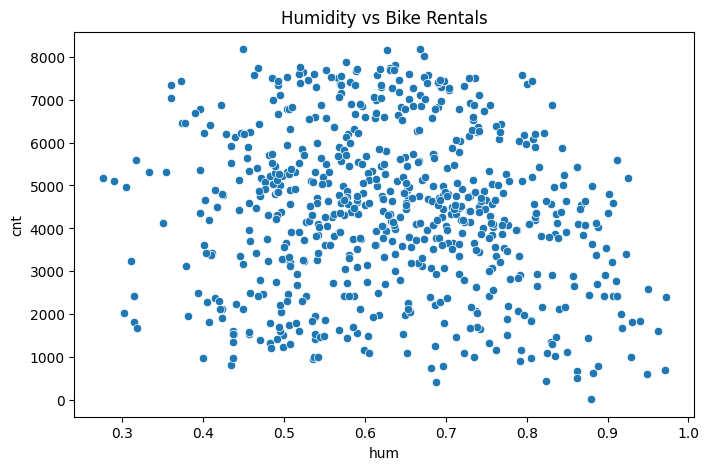

In [21]:
#humidity vs rentals

plt.figure(figsize=(8,5))
sns.scatterplot(x='hum', y='cnt', data=df)
plt.title("Humidity vs Bike Rentals")
plt.show()